# Relevant Links
Github: https://github.com/magloev/magloevIND320
Streamlit app: https://magloevind320.streamlit.app/

# AI Usage
for this project etc..

# Log
Started with some data exploration of the dataset reservoirs.csv. Found fill_level, stored_energy_TWh, fill_level_prev_week and fill_level_change to be relevant ones to show on the plot. Normalized them so that all values would fit reasonably in the plot. Decided to show only the total national data for now to make it simpler. Cut out stored_energy_TWh because correlation. Unusually small value for fill_level_change right at the start

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv('../data/reservoirs.csv')

#Renaming the columns to reasonable English equivalents
df = df.rename(columns= {
    "dato_Id" : "date",
    "omrType" : "area_type",
    "omrnr"   : "area_id",
    "iso_aar" : "iso_year",
    "iso_uke"  : "iso_week",
    "fyllingsgrad" : "fill_level",
    "kapasitet_TWh" : "capacity_TWh",
    "fylling_TWh" : "stored_energy_TWh",
    "neste_Publiseringsdato" : "next_publication_date", 
    "fyllingsgrad_forrige_uke" : "fill_level_prev_week",
    "endring_fyllingsgrad" : "fill_level_change" })

#Sort the data by date
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date")

df.head(20)

,date,area_type,area_id,iso_year,iso_week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,fill_level_prev_week,fill_level_change
3468,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
3361,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
5036,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3113,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
7739,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
11380,1995-01-08,VASS,2,1995,1,0.608856,23.237715,14.148431,0001-01-01T00:00:00,0.744693,-0.135837
14162,1995-01-08,VASS,1,1995,1,0.636038,36.044464,22.925638,0001-01-01T00:00:00,0.798825,-0.162787
11198,1995-01-08,VASS,3,1995,1,0.566906,28.155403,15.961480,0001-01-01T00:00:00,0.661432,-0.094525
8501,1995-01-08,NO,0,1995,1,0.608274,87.437580,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
13262,1995-01-15,VASS,2,1995,2,0.588298,23.237715,13.670702,0001-01-01T00:00:00,0.608854,-0.020556


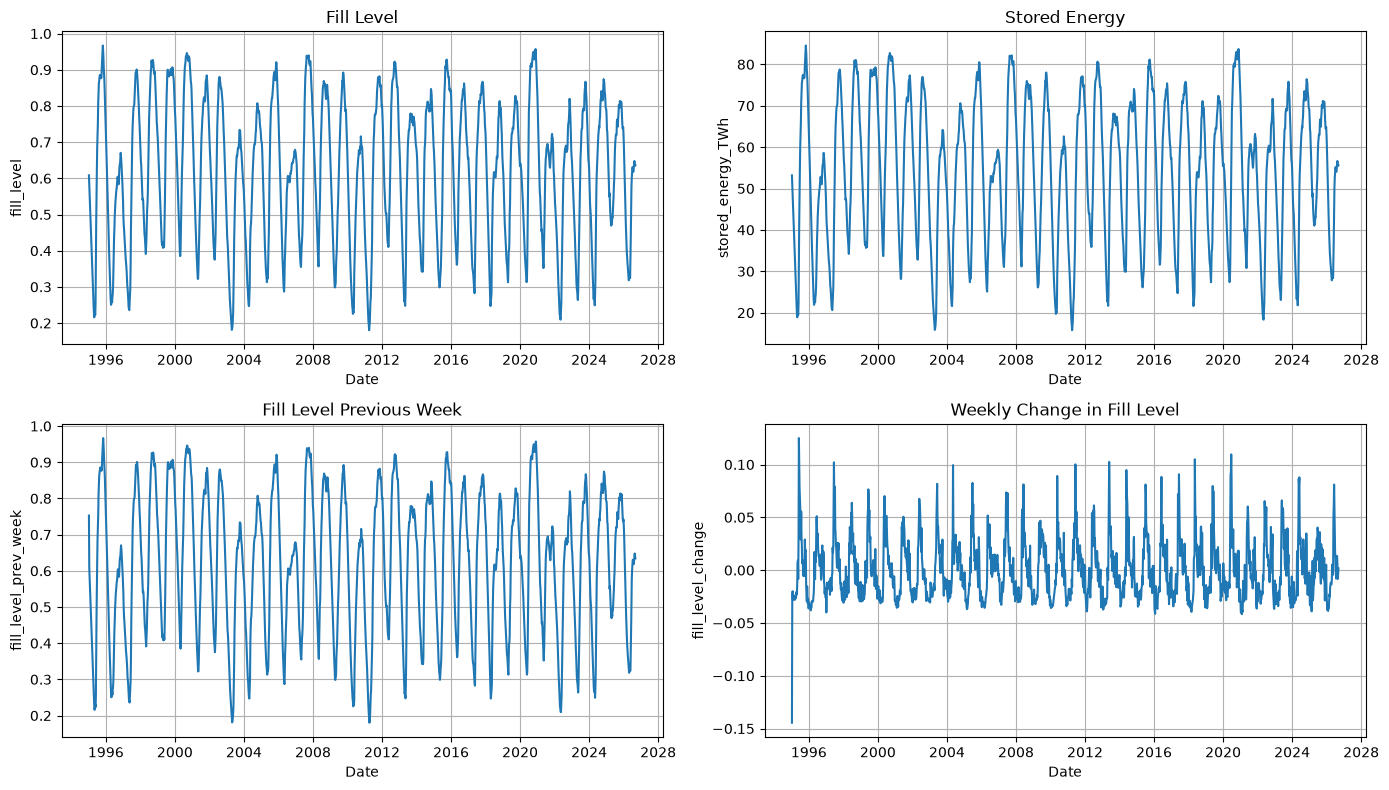

In [13]:
#Select the national data
df_no = df[(df["area_type"] == "NO")].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

columns = [
    "fill_level",
    "stored_energy_TWh",
    "fill_level_prev_week",
    "fill_level_change"
]

titles = [
    "Fill Level",
    "Stored Energy",
    "Fill Level Previous Week",
    "Weekly Change in Fill Level"
]

for ax, column, title in zip(axes.flatten(), columns, titles):
    ax.plot(df_no["date"], df_no[column])
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    ax.grid()

plt.tight_layout()
plt.show()




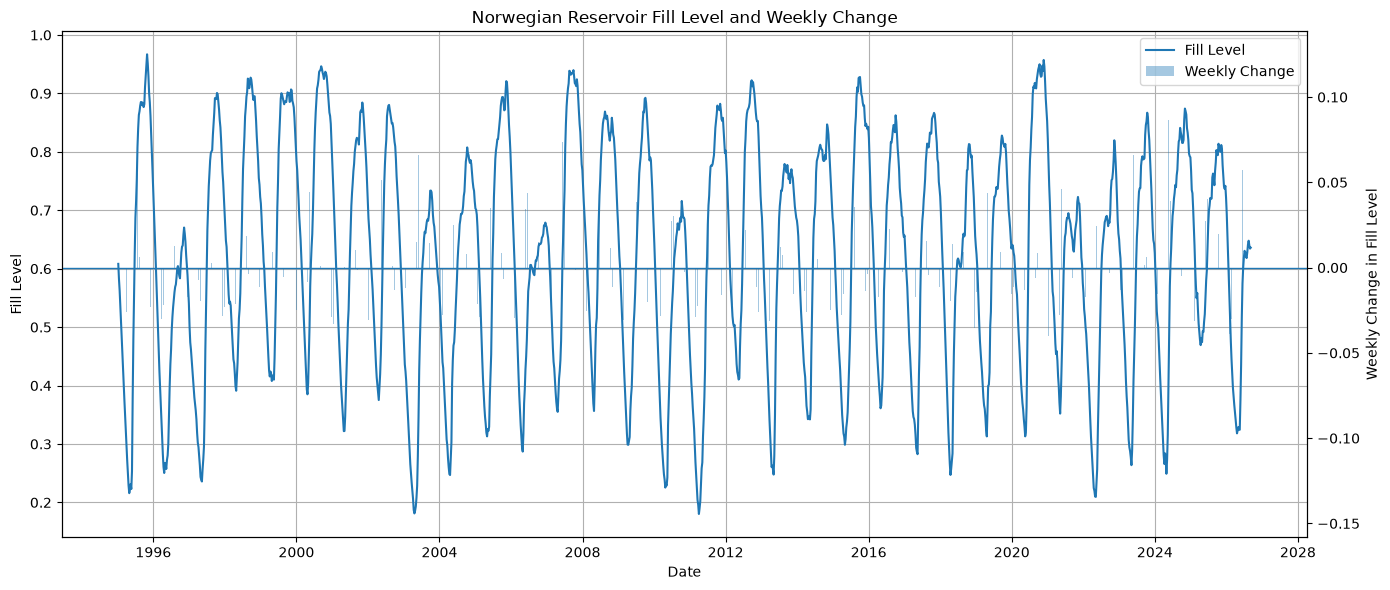

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Fill level - left y-axis
ax1.plot(
    df_no["date"],
    df_no["fill_level"],
    label="Fill Level"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Fill Level")
ax1.grid()

# Fill level change - right y-axis
ax2 = ax1.twinx()

ax2.plot(
    df_no["date"],
    df_no["fill_level_change"],
    label="Fill Level Change"
)

ax2.set_ylabel("Fill Level Change")

plt.title("Norwegian Reservoir Fill Level and Weekly Change")

fig.tight_layout()
plt.show()